# Day 6: Gradient Descent From Scratch

**Theme:** Implement multiple linear regression training manually with NumPy.

Today we will:

- load the Day 3 feature-selection dataset
- select a small feature set for optimization practice
- standardize the input features
- convert features and target to NumPy arrays
- initialize `w` and `b`
- define vectorized `predict`, `compute_cost`, and `gradient_descent` functions
- train a scratch linear regression model with a fixed learning rate and iteration count
- plot cost versus iteration
- compare scratch results with scikit-learn `LinearRegression`
- inspect sample scratch predictions

Week 2 notation:

```text
prediction = X @ w + b
cost      = mean squared error / 2
w         = learned feature weights
b         = learned bias / intercept
alpha     = learning rate
```

Gradient descent repeatedly updates `w` and `b` to reduce cost. If the learning rate is reasonable and the features are scaled, cost should go down over time.


## 1. Imports

We use NumPy for the scratch implementation and scikit-learn only for scaling and comparison.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)


## 2. Load The Day 3 Feature Dataset

Day 6 uses the feature table created on Day 3. If this file is missing, run `day_03_feature_selection.ipynb` first.


In [2]:
feature_candidates = [
    Path("../data/processed/gaia_day3_feature_selection.csv"),
    Path("data/processed/gaia_day3_feature_selection.csv"),
    Path("gaia-explorer/data/processed/gaia_day3_feature_selection.csv"),
]

FEATURE_PATH = next((path for path in feature_candidates if path.exists()), None)

if FEATURE_PATH is None:
    searched = "\n".join(str(path) for path in feature_candidates)
    raise FileNotFoundError(
        "Could not find Day 3 feature data. Run day_03_feature_selection.ipynb first.\n"
        f"Searched:\n{searched}"
    )

feature_df = pd.read_csv(FEATURE_PATH)
print(f"Loaded Day 3 feature data from: {FEATURE_PATH}")
print("Feature dataset shape:", feature_df.shape)
feature_df.head()


Loaded Day 3 feature data from: ../data/processed/gaia_day3_feature_selection.csv
Feature dataset shape: (2413, 6)


,source_id,abs_g_mag,bp_rp,parallax_snr,ra,dec
0,137338902210136064,7.400051,1.725426,9.333179,45.039785,35.288983
1,137341135593106176,4.617324,0.926100,25.084431,45.141976,35.385239
2,137342028946292224,10.602563,3.103573,10.161903,45.154690,35.461248
3,137345052603307136,6.335299,1.242174,18.125324,44.952444,35.304778
4,137346220834302080,6.432088,1.309051,33.519712,44.944379,35.374441


## 3. Select Features And Target

For scratch gradient descent, use a small feature set so the math stays readable:

```python
feature_columns = ["bp_rp", "parallax_snr"]
y = abs_g_mag
```

`bp_rp` is the physical color feature. `parallax_snr` is a measurement-quality diagnostic feature. Because it contains `parallax`, it carries indirect leakage risk for a final physical model, but it is useful here for practicing multi-feature gradient descent with two inputs.


In [3]:
feature_columns = ["bp_rp", "parallax_snr"]
target_column = "abs_g_mag"

required_columns = feature_columns + [target_column]
missing_required_columns = [col for col in required_columns if col not in feature_df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

modeling_df = feature_df.dropna(subset=required_columns).copy()

X_unscaled = modeling_df[feature_columns]
y_series = modeling_df[target_column]

feature_summary = pd.DataFrame(
    [
        {
            "column": "bp_rp",
            "role": "physical feature",
            "meaning": "Color index; lower is bluer/hotter, higher is redder/cooler.",
        },
        {
            "column": "parallax_snr",
            "role": "diagnostic feature",
            "meaning": "Parallax reliability; included here for optimization practice, not final physical interpretation.",
        },
        {
            "column": "abs_g_mag",
            "role": "target",
            "meaning": "Absolute Gaia G magnitude; lower values are brighter.",
        },
    ]
)

print("Rows available for Day 6:", len(modeling_df))
feature_summary


Rows available for Day 6: 2413


,column,role,meaning
0,bp_rp,physical feature,"Color index; lower is bluer/hotter, higher is ..."
1,parallax_snr,diagnostic feature,Parallax reliability; included here for optimi...
2,abs_g_mag,target,Absolute Gaia G magnitude; lower values are br...


## 4. Standardize Inputs And Convert To NumPy

Gradient descent is sensitive to feature scale. `bp_rp` is around `0` to `5`, while `parallax_snr` can range from `5` to hundreds. Standardization puts both columns on comparable numeric scales:

```text
scaled_value = (value - mean) / standard_deviation
```

We keep `y` in real `abs_g_mag` units so predictions and errors are still interpretable.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)
y = y_series.to_numpy(dtype=float)

X = X_scaled.astype(float)

scaling_summary = pd.DataFrame(
    {
        "feature": feature_columns,
        "training_mean": scaler.mean_,
        "training_scale_std": scaler.scale_,
    }
)

print("X shape:", X.shape)
print("y shape:", y.shape)
scaling_summary


X shape: (2413, 2)
y shape: (2413,)


,feature,training_mean,training_scale_std
0,bp_rp,1.537373,0.628491
1,parallax_snr,24.511184,42.727418


In [5]:
scaled_preview = pd.DataFrame(X, columns=[f"scaled_{col}" for col in feature_columns])
scaled_preview["abs_g_mag"] = y
scaled_preview.head()


,scaled_bp_rp,scaled_parallax_snr,abs_g_mag
0,0.299213,-0.355229,7.400051
1,-0.972605,0.013416,4.617324
2,2.492002,-0.335833,10.602563
3,-0.469695,-0.149456,6.335299
4,-0.363287,0.210837,6.432088


## 5. Define Vectorized Scratch Functions

These functions implement the same linear regression objective from the course:

```text
prediction = X @ w + b
error      = prediction - y
cost       = sum(error^2) / (2m)
```

The gradients are:

```text
dj_dw = X.T @ error / m
dj_db = sum(error) / m
```

Then gradient descent updates:

```text
w = w - alpha * dj_dw
b = b - alpha * dj_db
```


In [6]:
def predict(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    """Return vectorized linear predictions for all rows."""
    return X @ w + b


def compute_cost(X: np.ndarray, y: np.ndarray, w: np.ndarray, b: float) -> float:
    """Compute mean squared error cost divided by 2, matching Week 2 notation."""
    m = X.shape[0]
    errors = predict(X, w, b) - y
    return float((errors @ errors) / (2 * m))


def gradient_descent(
    X: np.ndarray,
    y: np.ndarray,
    w_init: np.ndarray,
    b_init: float,
    learning_rate: float,
    iterations: int,
) -> tuple[np.ndarray, float, list[float]]:
    """Run vectorized batch gradient descent for multiple linear regression."""
    m = X.shape[0]
    w = w_init.astype(float).copy()
    b = float(b_init)
    cost_history = []

    for iteration in range(iterations):
        errors = predict(X, w, b) - y
        dj_dw = (X.T @ errors) / m
        dj_db = np.sum(errors) / m

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history


## 6. Configure And Run Gradient Descent

We initialize weights and bias at zero, then train for a fixed number of iterations.

A learning rate that is too small learns slowly. A learning rate that is too large can make the cost bounce around or diverge. With standardized inputs, `0.05` is stable for this dataset.


In [7]:
learning_rate = 0.05
iterations = 2_000

w_init = np.zeros(X.shape[1])
b_init = 0.0

initial_cost = compute_cost(X, y, w_init, b_init)
w_scratch, b_scratch, cost_history = gradient_descent(
    X,
    y,
    w_init,
    b_init,
    learning_rate=learning_rate,
    iterations=iterations,
)
final_cost = cost_history[-1]

training_summary = pd.DataFrame(
    [
        {"item": "learning_rate", "value": learning_rate},
        {"item": "iterations", "value": iterations},
        {"item": "initial_cost", "value": initial_cost},
        {"item": "final_cost", "value": final_cost},
        {"item": "cost_reduction", "value": initial_cost - final_cost},
    ]
)

training_summary


,item,value
0,learning_rate,0.050000
1,iterations,2000.000000
2,initial_cost,23.359967
3,final_cost,1.244646
4,cost_reduction,22.115322


## 7. Plot Cost Versus Iteration

A good run should show cost decreasing and then flattening as the model approaches its best linear fit.


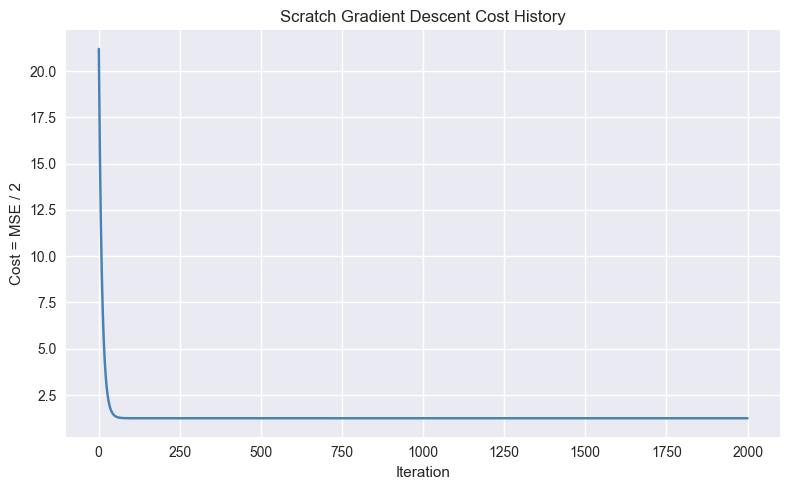

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(1, iterations + 1), cost_history, color="steelblue")
ax.set_title("Scratch Gradient Descent Cost History")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost = MSE / 2")

plt.tight_layout()
plt.show()


## 8. Inspect Final Scratch Weights And Bias

Each learned weight belongs to one scaled feature. Because the inputs are standardized, a weight tells us the expected change in predicted `abs_g_mag` for a one-standard-deviation increase in that feature, holding the other feature fixed.


In [9]:
scratch_parameters = pd.DataFrame(
    {
        "feature": feature_columns,
        "scratch_weight": w_scratch,
        "absolute_weight": np.abs(w_scratch),
        "interpretation_note": [
            "Positive means redder/cooler stars are predicted fainter because larger abs_g_mag means fainter.",
            "Diagnostic measurement-quality feature; interpret cautiously because it contains parallax.",
        ],
    }
).sort_values("absolute_weight", ascending=False)

scratch_bias_table = pd.DataFrame(
    [{"parameter": "b_scratch", "value": b_scratch, "meaning": "Prediction when scaled features are at their means."}]
)

print("Scratch bias:")
display(scratch_bias_table)

print("Scratch weights:")
scratch_parameters


Scratch bias:


,parameter,value,meaning
0,b_scratch,6.296961,Prediction when scaled features are at their m...


Scratch weights:


,feature,scratch_weight,absolute_weight,interpretation_note
0,bp_rp,2.137193,2.137193,Positive means redder/cooler stars are predict...
1,parallax_snr,-0.022849,0.022849,Diagnostic measurement-quality feature; interp...


## 9. Compare Scratch Results With Scikit-Learn

Scikit-learn solves the same least-squares problem directly. If our gradient descent implementation is correct and has converged, scratch weights and predictions should be very close to scikit-learn's results.


In [10]:
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

sklearn_predictions = sklearn_model.predict(X)
scratch_predictions = predict(X, w_scratch, b_scratch)

comparison_table = pd.DataFrame(
    {
        "feature": feature_columns,
        "scratch_weight": w_scratch,
        "sklearn_coefficient": sklearn_model.coef_,
        "difference": w_scratch - sklearn_model.coef_,
    }
)

comparison_summary = pd.DataFrame(
    [
        {
            "item": "scratch_bias",
            "value": b_scratch,
        },
        {
            "item": "sklearn_intercept",
            "value": sklearn_model.intercept_,
        },
        {
            "item": "max_abs_prediction_difference",
            "value": np.max(np.abs(scratch_predictions - sklearn_predictions)),
        },
        {
            "item": "scratch_final_cost",
            "value": compute_cost(X, y, w_scratch, b_scratch),
        },
        {
            "item": "sklearn_cost",
            "value": compute_cost(X, y, sklearn_model.coef_, sklearn_model.intercept_),
        },
    ]
)

print("Weight comparison:")
display(comparison_table)

print("Summary comparison:")
comparison_summary


Weight comparison:


,feature,scratch_weight,sklearn_coefficient,difference
0,bp_rp,2.137193,2.137193,-5.329071e-15
1,parallax_snr,-0.022849,-0.022849,-7.008283e-16


Summary comparison:


,item,value
0,scratch_bias,6.296961e+00
1,sklearn_intercept,6.296961e+00
2,max_abs_prediction_difference,3.907985e-14
3,scratch_final_cost,1.244646e+00
4,sklearn_cost,1.244646e+00


## 10. Sample Scratch Predictions

These rows compare actual `abs_g_mag`, scratch gradient-descent predictions, and scikit-learn predictions.


In [11]:
sample_indices = modeling_df.index[:10]

sample_predictions = modeling_df.loc[sample_indices, ["source_id", "abs_g_mag"] + feature_columns].copy()
sample_positions = [modeling_df.index.get_loc(index) for index in sample_indices]

sample_predictions["scratch_predicted_abs_g_mag"] = scratch_predictions[sample_positions]
sample_predictions["sklearn_predicted_abs_g_mag"] = sklearn_predictions[sample_positions]
sample_predictions["scratch_residual"] = sample_predictions["abs_g_mag"] - sample_predictions["scratch_predicted_abs_g_mag"]

sample_predictions


,source_id,abs_g_mag,bp_rp,parallax_snr,scratch_predicted_abs_g_mag,sklearn_predicted_abs_g_mag,scratch_residual
0,137338902210136064,7.400051,1.725426,9.333179,6.944554,6.944554,0.455497
1,137341135593106176,4.617324,0.926100,25.084431,4.218009,4.218009,0.399315
2,137342028946292224,10.602563,3.103573,10.161903,11.630524,11.630524,-1.027961
3,137345052603307136,6.335299,1.242174,18.125324,5.296547,5.296547,1.038753
4,137346220834302080,6.432088,1.309051,33.519712,5.515729,5.515729,0.916359
5,137346358273826048,13.807643,1.635696,5.595345,6.641427,6.641427,7.166216
6,137349137117125760,9.285891,2.104134,5.443279,8.234437,8.234437,1.051455
7,137349210131541504,4.987060,0.993360,17.709444,4.450671,4.450671,0.536389
8,137349622448400768,4.236101,1.034535,8.590819,4.595566,4.595566,-0.359465
9,137349656808137728,4.742642,0.987767,13.554638,4.433876,4.433876,0.308767


## 11. Optional Learning Rate Check

This quick check shows how different learning rates affect final cost after the same number of iterations. The goal is not to tune the best model here; it is to see optimization behavior.


In [12]:
learning_rate_rows = []

for candidate_learning_rate in [0.001, 0.005, 0.01, 0.05, 0.2]:
    candidate_w, candidate_b, candidate_history = gradient_descent(
        X,
        y,
        w_init,
        b_init,
        learning_rate=candidate_learning_rate,
        iterations=1_000,
    )
    learning_rate_rows.append(
        {
            "learning_rate": candidate_learning_rate,
            "initial_cost": initial_cost,
            "final_cost_after_1000_iterations": candidate_history[-1],
            "cost_decreased": candidate_history[-1] < initial_cost,
        }
    )

learning_rate_table = pd.DataFrame(learning_rate_rows)
learning_rate_table


,learning_rate,initial_cost,final_cost_after_1000_iterations,cost_decreased
0,0.001,23.359967,4.233150,True
1,0.005,23.359967,1.245676,True
2,0.010,23.359967,1.244646,True
3,0.050,23.359967,1.244646,True
4,0.200,23.359967,1.244646,True


## 12. Save Day 6 Scratch Outputs

These files preserve the scratch parameters and prediction comparison for later review.


In [13]:
parameter_output_candidates = [
    Path("../data/processed/gaia_day6_scratch_gradient_descent_parameters.csv"),
    Path("data/processed/gaia_day6_scratch_gradient_descent_parameters.csv"),
    Path("gaia-explorer/data/processed/gaia_day6_scratch_gradient_descent_parameters.csv"),
]
prediction_output_candidates = [
    Path("../data/processed/gaia_day6_scratch_gradient_descent_predictions.csv"),
    Path("data/processed/gaia_day6_scratch_gradient_descent_predictions.csv"),
    Path("gaia-explorer/data/processed/gaia_day6_scratch_gradient_descent_predictions.csv"),
]

PARAMETER_OUTPUT_PATH = next(
    (path for path in parameter_output_candidates if path.parent.exists()),
    parameter_output_candidates[0],
)
PREDICTION_OUTPUT_PATH = next(
    (path for path in prediction_output_candidates if path.parent.exists()),
    prediction_output_candidates[0],
)

PARAMETER_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

parameter_output = scratch_parameters.copy()
parameter_output["scratch_bias"] = b_scratch
parameter_output["learning_rate"] = learning_rate
parameter_output["iterations"] = iterations
parameter_output["final_cost"] = final_cost
parameter_output.to_csv(PARAMETER_OUTPUT_PATH, index=False)

prediction_output = modeling_df[["source_id", "abs_g_mag"] + feature_columns].copy()
prediction_output["scratch_predicted_abs_g_mag"] = scratch_predictions
prediction_output["sklearn_predicted_abs_g_mag"] = sklearn_predictions
prediction_output["scratch_residual"] = prediction_output["abs_g_mag"] - prediction_output["scratch_predicted_abs_g_mag"]
prediction_output.to_csv(PREDICTION_OUTPUT_PATH, index=False)

print(f"Saved scratch parameters to: {PARAMETER_OUTPUT_PATH}")
print(f"Saved scratch predictions to: {PREDICTION_OUTPUT_PATH}")
print("Prediction rows:", len(prediction_output))


Saved scratch parameters to: ../data/processed/gaia_day6_scratch_gradient_descent_parameters.csv
Saved scratch predictions to: ../data/processed/gaia_day6_scratch_gradient_descent_predictions.csv
Prediction rows: 2413


## Reflection Questions And Starter Answers

1. What happens when the learning rate is too large?

   **Starter answer:** The cost can bounce around, decrease slowly, or diverge instead of settling. A large update may step past the minimum rather than moving toward it.

2. Why does feature scaling matter for gradient descent?

   **Starter answer:** Scaling puts features on comparable numeric ranges. Without scaling, a feature with a large range can dominate the gradient, making learning unstable or slow.

3. Did the scratch model learn similar behavior to scikit-learn?

   **Starter answer:** Yes, if the scratch weights, bias, cost, and predictions are close to the scikit-learn values. That means gradient descent found nearly the same least-squares solution.

4. Why keep `y` in real `abs_g_mag` units?

   **Starter answer:** Keeping `y` unscaled makes predictions and residuals easy to interpret as magnitude differences. We scale the input features for optimization, but the target can remain in astronomy units.

5. Why is `parallax_snr` included here even though it is diagnostic?

   **Starter answer:** Day 6 is mainly about optimization mechanics with multiple inputs. `parallax_snr` gives a second numeric feature for the gradient-descent exercise, but final physical interpretation should still treat it cautiously because it contains parallax.
